# AUTOTROLEJ Static Data Analysis

This notebook explores Rijeka AUTOTROLEJ static datasets end-to-end: ingestion, profiling, consistency checks, visualization, and delay-readiness diagnostics.

Datasets:
- `ATlinije.json`
- `ATstanice.json`
- `ATvoznired.json`
- `ATvoznired-tjedan.json`
- `ATvoznired-subota.json`
- `ATvoznired-nedjelja.json`

Narrative flow:
1. Set up environment and configuration
2. Load and inspect source data
3. Profile quality and validate assumptions
4. Visualize service patterns and spatial intensity
5. Summarize findings and prepare for delay-calculation work

## 1) Environment Setup and Imports
Install/verify dependencies, import libraries, and print versions for reproducibility.

In [1]:
import json
import sys
import time
from pathlib import Path
from typing import Dict, Any
from urllib.request import urlopen, Request

import pandas as pd

print(f"Python: {sys.version.split()[0]}")
print(f"pandas: {pd.__version__}")

Python: 3.14.3
pandas: 3.0.0


## 2) Project Configuration and Constants
Define URLs, paths, and runtime flags in one place.

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "eda" else Path.cwd().resolve()
DATA_DIR = PROJECT_ROOT / "eda" / "data_raw"
DATA_DIR.mkdir(parents=True, exist_ok=True)

REFRESH_CACHE = False
TIMEOUT_SECONDS = 30

DATA_SOURCES = {
    "linije": "http://e-usluge2.rijeka.hr/OpenData/ATlinije.json",
    "stanice": "http://e-usluge2.rijeka.hr/OpenData/ATstanice.json",
    "voznired_dnevni": "http://e-usluge2.rijeka.hr/OpenData/ATvoznired.json",
    "voznired_tjedan": "http://e-usluge2.rijeka.hr/OpenData/ATvoznired-tjedan.json",
    "voznired_subota": "http://e-usluge2.rijeka.hr/OpenData/ATvoznired-subota.json",
    "voznired_nedjelja": "http://e-usluge2.rijeka.hr/OpenData/ATvoznired-nedjelja.json",
}

CACHE_FILES = {name: DATA_DIR / f"{name}.json" for name in DATA_SOURCES}

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"REFRESH_CACHE: {REFRESH_CACHE}")

PROJECT_ROOT: /Users/ediprodan/Documents/Projects/arRIval
DATA_DIR: /Users/ediprodan/Documents/Projects/arRIval/eda/data_raw
REFRESH_CACHE: False


## 3) Data/Input Bootstrap
Load source files (download + cache), then display shape and sample records.

In [3]:
def fetch_json(url: str, timeout: int = TIMEOUT_SECONDS) -> Any:
    request = Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urlopen(request, timeout=timeout) as response:
        return json.loads(response.read().decode("utf-8"))


def load_with_cache(name: str, url: str, refresh: bool = REFRESH_CACHE) -> Any:
    cache_file = CACHE_FILES[name]
    if cache_file.exists() and not refresh:
        with cache_file.open("r", encoding="utf-8") as f:
            return json.load(f)

    data = fetch_json(url)
    with cache_file.open("w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False)
    return data


def to_dataframe(data: Any) -> pd.DataFrame:
    if isinstance(data, list):
        return pd.json_normalize(data)
    if isinstance(data, dict):
        if all(isinstance(v, dict) for v in data.values()):
            return pd.json_normalize(list(data.values()))
        return pd.json_normalize(data)
    raise ValueError(f"Unsupported JSON type: {type(data)}")

raw_data: Dict[str, Any] = {}
dfs: Dict[str, pd.DataFrame] = {}

for dataset_name, dataset_url in DATA_SOURCES.items():
    started = time.time()
    raw = load_with_cache(dataset_name, dataset_url)
    frame = to_dataframe(raw)
    raw_data[dataset_name] = raw
    dfs[dataset_name] = frame
    elapsed = time.time() - started
    print(f"Loaded {dataset_name:<16} rows={len(frame):>7} cols={frame.shape[1]:>3} in {elapsed:.2f}s")

Loaded linije           rows=  20581 cols=  8 in 0.09s
Loaded stanice          rows=   1186 cols=  5 in 0.00s
Loaded voznired_dnevni  rows=  20581 cols= 14 in 0.13s
Loaded voznired_tjedan  rows=  36324 cols= 14 in 0.24s
Loaded voznired_subota  rows=  20581 cols= 14 in 0.13s
Loaded voznired_nedjelja rows=  20210 cols= 14 in 0.14s


In [4]:
for name, frame in dfs.items():
    print(f"\n{name.upper()} -> shape={frame.shape}")
    display(frame.head(3))


LINIJE -> shape=(20581, 8)


,Id,LinVarId,BrojLinije,NazivVarijanteLinije,Smjer,StanicaId,RedniBrojStanice,Varijanta
0,1,1-B-0,1,BIVIO - CENTAR - PEĆINE,B,1795,1,0
1,2,1-B-0,1,BIVIO - CENTAR - PEĆINE,B,1795,1,0
2,3,1-B-0,1,BIVIO - CENTAR - PEĆINE,B,1795,1,0



STANICE -> shape=(1186, 5)


,StanicaId,Naziv,Kratki,GpsX,GpsY
0,1734,1. maja,1. maja,14.433160,45.333713
1,1735,1. maja,1. maja,14.433233,45.334308
2,1736,3. maj,3. maj,14.392678,45.339517



VOZNIRED_DNEVNI -> shape=(20581, 14)


...

,Id,PolazakId,StanicaId,LinVarId,Polazak,RedniBrojStanice,BrojLinije,Smjer,Varijanta,NazivVarijanteLinije,PodrucjePrometa,GpsX,GpsY,Naziv
0,1,2118443,2364,1-A-0,05:57:00.0000000,1,1,A,0,PEĆINE - CENTAR - BIVIO,Lokalni,14.472840,45.314330,Pećine Plumbum
1,2,2118443,2035,1-A-0,05:59:00.0000000,2,1,A,0,PEĆINE - CENTAR - BIVIO,Lokalni,14.470423,45.316130,J.P.Kamova Tower
2,3,2118443,2034,1-A-0,06:00:00.0000000,3,1,A,0,PEĆINE - CENTAR - BIVIO,Lokalni,14.465713,45.319122,J.P.Kamova



VOZNIRED_SUBOTA -> shape=(20581, 14)


,Id,PolazakId,StanicaId,LinVarId,Polazak,RedniBrojStanice,BrojLinije,Smjer,Varijanta,NazivVarijanteLinije,PodrucjePrometa,GpsX,GpsY,Naziv
0,1,2128029,2364,1-A-0,05:10:00.0000000,1,1,A,0,PEĆINE - CENTAR - BIVIO,Lokalni,14.472840,45.314330,Pećine Plumbum
1,2,2128029,2035,1-A-0,05:12:00.0000000,2,1,A,0,PEĆINE - CENTAR - BIVIO,Lokalni,14.470423,45.316130,J.P.Kamova Tower
2,3,2128029,2034,1-A-0,05:12:00.0000000,3,1,A,0,PEĆINE - CENTAR - BIVIO,Lokalni,14.465713,45.319122,J.P.Kamova



VOZNIRED_NEDJELJA -> shape=(20210, 14)


,Id,PolazakId,StanicaId,LinVarId,Polazak,RedniBrojStanice,BrojLinije,Smjer,Varijanta,NazivVarijanteLinije,PodrucjePrometa,GpsX,GpsY,Naziv
0,1,2128623,1795,1-B-0,23:35:00.0000000,1,1,B,0,BIVIO - CENTAR - PEĆINE,Lokalni,14.358355,45.344672,Bivio okr.
1,2,2128623,1864,1-B-0,23:38:00.0000000,2,1,B,0,BIVIO - CENTAR - PEĆINE,Lokalni,14.368903,45.341965,Istarska
2,3,2128623,1781,1-B-0,23:39:00.0000000,3,1,B,0,BIVIO - CENTAR - PEĆINE,Lokalni,14.373520,45.341403,Bazeni Kantrida


## 4) Reusable Analysis Functions
Define helper functions for profiling, duplicate checks, and datetime normalization.

In [5]:
def profile_dataframe(df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    """Return column-level profiling stats for a dataset."""
    if df.empty:
        raise ValueError(f"Dataset '{dataset_name}' is empty.")

    rows = len(df)
    records = []
    for col in df.columns:
        null_count = int(df[col].isna().sum())
        records.append(
            {
                "dataset": dataset_name,
                "column": col,
                "dtype": str(df[col].dtype),
                "null_count": null_count,
                "null_pct": round((null_count / rows) * 100, 2),
                "n_unique": int(df[col].nunique(dropna=True)),
            }
        )
    return pd.DataFrame(records)


def duplicate_summary(df: pd.DataFrame, dataset_name: str) -> Dict[str, Any]:
    """Return duplicate metrics for full-row duplicates."""
    total_rows = len(df)
    dup_rows = int(df.duplicated().sum())
    return {
        "dataset": dataset_name,
        "rows": total_rows,
        "duplicate_rows": dup_rows,
        "duplicate_pct": round((dup_rows / total_rows) * 100, 2) if total_rows else 0.0,
    }


def parse_polazak_column(df: pd.DataFrame) -> pd.DataFrame:
    """Parse `Polazak` as datetime when present, keep original columns untouched."""
    out = df.copy()
    if "Polazak" in out.columns:
        out["Polazak_dt"] = pd.to_datetime(out["Polazak"], format="%H:%M:%S.%f", errors="coerce")
    return out

## 5) Data Quality Profiling Workflow
Run a full pass across datasets and collect comparable quality metrics.

In [6]:
t0 = time.time()

profiles = []
duplicate_reports = []
normalized_dfs: Dict[str, pd.DataFrame] = {}

for name, frame in dfs.items():
    normalized = parse_polazak_column(frame)
    normalized_dfs[name] = normalized
    profiles.append(profile_dataframe(normalized, name))
    duplicate_reports.append(duplicate_summary(normalized, name))

profile_df = pd.concat(profiles, ignore_index=True)
duplicate_df = pd.DataFrame(duplicate_reports)

print(f"Workflow runtime: {time.time() - t0:.2f}s")
print("\nDuplicate summary:")
display(duplicate_df.sort_values("duplicate_pct", ascending=False))

print("\nTop columns by null percentage:")
display(profile_df.sort_values("null_pct", ascending=False).head(20))

Workflow runtime: 0.25s

Duplicate summary:


,dataset,rows,duplicate_rows,duplicate_pct
0,linije,20581,0,0.0
1,stanice,1186,0,0.0
2,voznired_dnevni,20581,0,0.0
3,voznired_tjedan,36324,0,0.0
4,voznired_subota,20581,0,0.0
5,voznired_nedjelja,20210,0,0.0



Top columns by null percentage:


,dataset,column,dtype,null_count,null_pct,n_unique
12,stanice,GpsY,float64,9,0.76,1163
11,stanice,GpsX,float64,9,0.76,1169
0,linije,Id,int64,0,0.00,20581
48,voznired_subota,RedniBrojStanice,int64,0,0.00,45
53,voznired_subota,PodrucjePrometa,str,0,0.00,1
52,voznired_subota,NazivVarijanteLinije,str,0,0.00,155
51,voznired_subota,Varijanta,str,0,0.00,28
50,voznired_subota,Smjer,str,0,0.00,2
49,voznired_subota,BrojLinije,str,0,0.00,41
47,voznired_subota,Polazak,str,0,0.00,1417


In [13]:
missing_coords = stanice_base[stanice_base[["GpsX", "GpsY"]].isna().any(axis=1)].copy()

display(missing_coords)
print(f"Missing stations: {len(missing_coords)}")

,StanicaId,Naziv,Kratki,GpsX,GpsY
974,2946,PRIČUVA,PRIČUVA,NaN,NaN
1078,3052,ŠKOLJIĆ PUMPA,Školjić pumpa,NaN,NaN
1079,3053,DELTA - PRIČUVA,DELTA - PRIČUVA,NaN,NaN
1080,3054,INVALIDI,INVALIDI,NaN,NaN
1081,3055,UKINUTA,UKINUTA,NaN,NaN
1084,3058,Bazen Rijeka Pliva,Bazen škole,NaN,NaN
1108,4081,Češki dom,Češki dom,NaN,NaN
1177,4185,trsat groblje 1,trsat groblje 1,NaN,NaN
1178,4186,alibi 1,alibi 1,NaN,NaN


Missing coordinates: 9


In [7]:
# Cross-dataset consistency checks
linije_df = normalized_dfs["linije"]
stanice_df = normalized_dfs["stanice"]
voznired_df = normalized_dfs["voznired_dnevni"]

consistency = {}

if "StanicaId" in linije_df.columns and "StanicaId" in stanice_df.columns:
    linije_station_ids = set(linije_df["StanicaId"].dropna().astype(int).tolist())
    stanice_station_ids = set(stanice_df["StanicaId"].dropna().astype(int).tolist())
    missing_in_stanice = sorted(linije_station_ids - stanice_station_ids)
    consistency["linije_station_ids_missing_in_stanice"] = len(missing_in_stanice)
else:
    consistency["linije_station_ids_missing_in_stanice"] = "N/A"

if "LinVarId" in linije_df.columns and "LinVarId" in voznired_df.columns:
    linije_vars = set(linije_df["LinVarId"].dropna().astype(str).tolist())
    voznired_vars = set(voznired_df["LinVarId"].dropna().astype(str).tolist())
    consistency["voznired_linvar_not_in_linije"] = len(voznired_vars - linije_vars)
else:
    consistency["voznired_linvar_not_in_linije"] = "N/A"

consistency_df = pd.DataFrame([consistency])
display(consistency_df)

,linije_station_ids_missing_in_stanice,voznired_linvar_not_in_linije
0,0,0


## 6) Validation Checks
Run lightweight assertions to confirm expected schema and parse quality.

In [8]:
assert len(dfs) == len(DATA_SOURCES), "Not all datasets were loaded."
assert all(len(df) > 0 for df in dfs.values()), "At least one dataset is empty."

required_columns = {
    "linije": ["LinVarId", "StanicaId", "BrojLinije"],
    "stanice": ["StanicaId", "Naziv", "GpsX", "GpsY"],
    "voznired_dnevni": ["PolazakId", "StanicaId", "LinVarId", "Polazak"],
}

for dataset, cols in required_columns.items():
    missing = [c for c in cols if c not in dfs[dataset].columns]
    assert not missing, f"{dataset} missing columns: {missing}"

if "Polazak_dt" in normalized_dfs["voznired_dnevni"].columns:
    parsed_ratio = normalized_dfs["voznired_dnevni"]["Polazak_dt"].notna().mean()
    assert parsed_ratio > 0.95, f"Unexpected datetime parse ratio: {parsed_ratio:.2%}"

print("Validation passed")

Quick validation passed ✅


## 7) Dataset Summary
Build a compact overview table for loaded sources and cache outputs.

In [9]:
summary = pd.DataFrame(
    {
        "dataset": list(dfs.keys()),
        "rows": [len(dfs[k]) for k in dfs.keys()],
        "cols": [dfs[k].shape[1] for k in dfs.keys()],
        "cache_file": [str(CACHE_FILES[k]) for k in dfs.keys()],
    }
).sort_values("rows", ascending=False)

display(summary)

print("\nStatic data analysis setup is complete.")
print("Next step: add focused visuals (line coverage, station density, departure distributions).")

,dataset,rows,cols,cache_file
3,voznired_tjedan,36324,14,/Users/ediprodan/Documents/Projects/arRIval/ed...
0,linije,20581,8,/Users/ediprodan/Documents/Projects/arRIval/ed...
2,voznired_dnevni,20581,14,/Users/ediprodan/Documents/Projects/arRIval/ed...
4,voznired_subota,20581,14,/Users/ediprodan/Documents/Projects/arRIval/ed...
5,voznired_nedjelja,20210,14,/Users/ediprodan/Documents/Projects/arRIval/ed...
1,stanice,1186,5,/Users/ediprodan/Documents/Projects/arRIval/ed...



Static data analysis setup is complete.
Next step: add focused visuals (line coverage, station density, departure distributions).


## 8) Service Patterns and Spatial View
Visualize line activity, hourly service distribution, and station intensity on the map.

,BrojLinije,dnevni,tjedan,subota,nedjelja,total
23,2,2531,3007,2531,2531,10600
49,5,1532,2525,1532,1532,7121
53,6,1312,2066,1312,1312,6002
54,7,1225,1810,1225,1225,5485
55,7A,1200,1758,1200,1200,5358
0,1,1212,1702,1212,1212,5338
39,32,1113,1837,1113,1113,5176
30,26,924,1316,924,870,4034
6,11,936,1206,936,899,3977
37,3,800,987,800,800,3387


,hour,dnevni,tjedan,subota,nedjelja
0,0,95,63,95,95
1,1,89,6,89,89
2,2,77,2,77,77
3,3,96,12,96,96
4,4,226,177,226,226
5,5,1031,1566,1031,971
6,6,1334,2642,1334,1279
7,7,1193,2731,1193,1152
8,8,1023,1829,1023,1002
9,9,1120,1567,1120,1078


,StanicaId,departures_dnevni,Naziv,GpsX,GpsY
663,2641,288,Trg RH,14.440541,45.327044
751,2764,279,Žabica,14.437783,45.327255
673,2654,257,Tržnica,14.443947,45.324925
537,2474,257,Riječki neboder,14.438232,45.327845
146,1932,248,Fiumara A,14.446520,45.326130
90,1858,226,Delta,14.448008,45.324608
56,1812,224,Brajda,14.434123,45.329513
538,2475,224,Riva,14.440090,45.326378
756,2769,208,Željeznički kolodvor,14.431135,45.330372
757,2770,202,Željeznički kolodvor,14.431097,45.330317


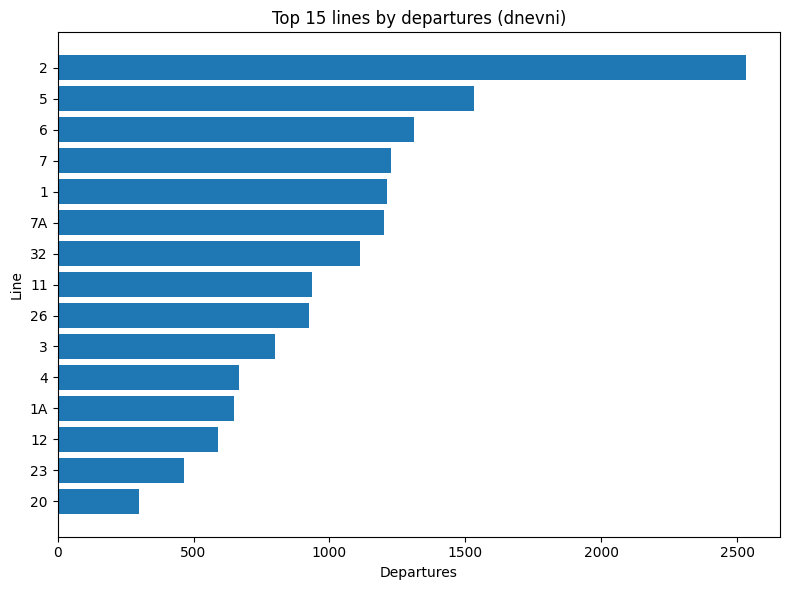

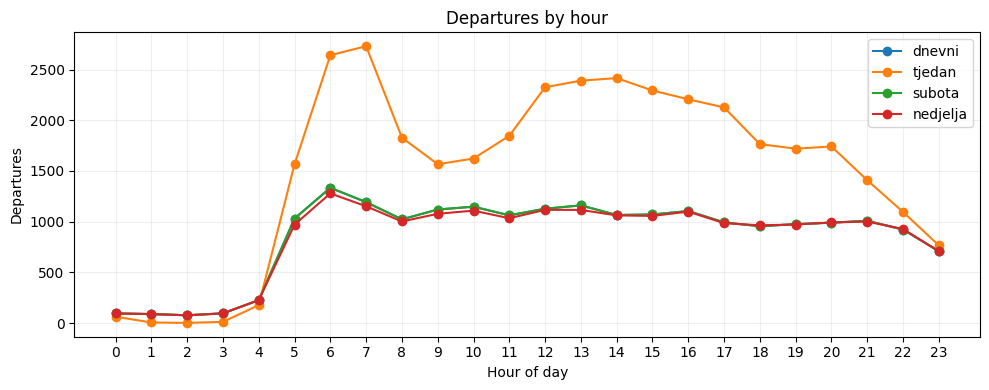

In [14]:
day_type_frames = {
    "dnevni": normalized_dfs.get("voznired_dnevni", pd.DataFrame()),
    "tjedan": normalized_dfs.get("voznired_tjedan", pd.DataFrame()),
    "subota": normalized_dfs.get("voznired_subota", pd.DataFrame()),
    "nedjelja": normalized_dfs.get("voznired_nedjelja", pd.DataFrame()),
}

stanice_base = dfs.get("stanice", pd.DataFrame())

# 1) Top lines by day type
line_counts_parts = []
for day_type, frame in day_type_frames.items():
    if not frame.empty and "BrojLinije" in frame.columns:
        part = (
            frame.groupby("BrojLinije", dropna=False)
            .size()
            .rename(day_type)
            .reset_index()
        )
        line_counts_parts.append(part)

if line_counts_parts:
    top_lines_by_day = line_counts_parts[0]
    for part in line_counts_parts[1:]:
        top_lines_by_day = top_lines_by_day.merge(part, on="BrojLinije", how="outer")
    top_lines_by_day = top_lines_by_day.fillna(0)
    value_columns = [column_name for column_name in top_lines_by_day.columns if column_name != "BrojLinije"]
    for column_name in value_columns:
        top_lines_by_day[column_name] = top_lines_by_day[column_name].astype(int)
    top_lines_by_day["total"] = top_lines_by_day[value_columns].sum(axis=1)
    top_lines_by_day = top_lines_by_day.sort_values("total", ascending=False)
    display(top_lines_by_day.head(15))
else:
    top_lines_by_day = pd.DataFrame()
    print("Top lines table: N/A")

# 2) Departures by hour
hour_parts = []
for day_type, frame in day_type_frames.items():
    if not frame.empty and "Polazak_dt" in frame.columns:
        valid_departures = frame.dropna(subset=["Polazak_dt"]).copy()
        if not valid_departures.empty:
            valid_departures["hour"] = valid_departures["Polazak_dt"].dt.hour
            part = valid_departures.groupby("hour").size().rename(day_type).reset_index()
            hour_parts.append(part)

if hour_parts:
    departures_by_hour = hour_parts[0]
    for part in hour_parts[1:]:
        departures_by_hour = departures_by_hour.merge(part, on="hour", how="outer")
    departures_by_hour = departures_by_hour.fillna(0).sort_values("hour")
    day_columns = [column_name for column_name in departures_by_hour.columns if column_name != "hour"]
    for column_name in day_columns:
        departures_by_hour[column_name] = departures_by_hour[column_name].astype(int)
    display(departures_by_hour)
else:
    departures_by_hour = pd.DataFrame()
    print("Departures by hour: N/A")

# 3) Top stations by departures (dnevni)
if not day_type_frames["dnevni"].empty and "StanicaId" in day_type_frames["dnevni"].columns:
    station_counts = (
        day_type_frames["dnevni"].groupby("StanicaId", dropna=False)
        .size()
        .rename("departures_dnevni")
        .reset_index()
    )
    station_meta = stanice_base[
        [column_name for column_name in ["StanicaId", "Naziv", "GpsX", "GpsY"] if column_name in stanice_base.columns]
    ].drop_duplicates()
    top_stations = (
        station_counts.merge(station_meta, on="StanicaId", how="left")
        .sort_values("departures_dnevni", ascending=False)
    )
    display(top_stations.head(15))
else:
    top_stations = pd.DataFrame()
    print("Top stations table: N/A")

# Optional plots (first two in matplotlib)
try:
    import matplotlib.pyplot as plt

    if not top_lines_by_day.empty and "dnevni" in top_lines_by_day.columns:
        plot_lines = top_lines_by_day.head(15).sort_values("dnevni")
        plt.figure(figsize=(8, 6))
        plt.barh(plot_lines["BrojLinije"].astype(str), plot_lines["dnevni"])
        plt.title("Top 15 lines by departures (dnevni)")
        plt.xlabel("Departures")
        plt.ylabel("Line")
        plt.tight_layout()
        plt.show()

    if not departures_by_hour.empty:
        plt.figure(figsize=(10, 4))
        for column_name in [name for name in departures_by_hour.columns if name != "hour"]:
            plt.plot(
                departures_by_hour["hour"],
                departures_by_hour[column_name],
                marker="o",
                label=column_name,
            )
        plt.title("Departures by hour")
        plt.xlabel("Hour of day")
        plt.ylabel("Departures")
        plt.xticks(range(0, 24, 1))
        plt.grid(alpha=0.2)
        plt.legend()
        plt.tight_layout()
        plt.show()
except Exception as plot_error:
    print(f"Matplotlib plots skipped: {plot_error}")

# 4) Station intensity map inline in notebook (Plotly)
if not top_stations.empty and all(column_name in top_stations.columns for column_name in ["GpsX", "GpsY"]):
    map_points = top_stations.dropna(subset=["GpsX", "GpsY"]).head(200).copy()
    if not map_points.empty:
        map_points["lat"] = map_points["GpsY"]
        map_points["lon"] = map_points["GpsX"]

        try:
            import plotly.express as px

            plotly_map = px.scatter_map(
                map_points,
                lat="lat",
                lon="lon",
                size="departures_dnevni",
                hover_name="Naziv",
                hover_data={
                    "StanicaId": True,
                    "departures_dnevni": True,
                    "lat": False,
                    "lon": False,
                },
                zoom=12,
                title="Station departure intensity (dnevni)",
                height=650,
                size_max=30,
            )
            plotly_map.update_layout(map_style="carto-positron", margin={"l": 0, "r": 0, "t": 50, "b": 0})
            plotly_map.show()
        except Exception as plotly_error:
            print(f"Plotly map skipped: {plotly_error}")

## 9) Key Findings
Summarize practical takeaways from profiling and visualization outputs.

In [11]:
print("Simple insights\n")

linije_base = dfs.get("linije", pd.DataFrame())
stanice_base = dfs.get("stanice", pd.DataFrame())
voznired_dnevni_base = day_type_frames.get("dnevni", pd.DataFrame()) if "day_type_frames" in globals() else normalized_dfs.get("voznired_dnevni", pd.DataFrame())

# 1) Dataset row comparison
if "summary" in globals() and not summary.empty and "rows" in summary.columns and "dataset" in summary.columns:
    largest = summary.loc[summary["rows"].idxmax()]
    smallest = summary.loc[summary["rows"].idxmin()]
    print(f"- Largest dataset: {largest['dataset']} ({int(largest['rows'])} rows)")
    print(f"- Smallest dataset: {smallest['dataset']} ({int(smallest['rows'])} rows)")
else:
    print("- Dataset row comparison: N/A")

# 2) Station geo completeness
if not stanice_base.empty and all(c in stanice_base.columns for c in ["GpsX", "GpsY"]):
    total_stations = len(stanice_base)
    missing_geo = int(stanice_base[["GpsX", "GpsY"]].isna().any(axis=1).sum())
    missing_geo_pct = (missing_geo / total_stations * 100) if total_stations else 0
    print(f"- Stations with missing coordinates: {missing_geo}/{total_stations} ({missing_geo_pct:.2f}%)")
else:
    print("- Station geo completeness: N/A")

# 3) Line variant coverage
if not linije_base.empty and not voznired_dnevni_base.empty and "LinVarId" in linije_base.columns and "LinVarId" in voznired_dnevni_base.columns:
    linije_var = set(linije_base["LinVarId"].dropna().astype(str))
    voznired_var = set(voznired_dnevni_base["LinVarId"].dropna().astype(str))
    overlap = len(linije_var & voznired_var)
    overlap_pct = (overlap / len(linije_var) * 100) if len(linije_var) else 0
    coverage_msg = f"linije={len(linije_var)}, voznired_dnevni={len(voznired_var)}, overlap={overlap} ({overlap_pct:.2f}%)"
    print(f"- Line variant coverage: {coverage_msg}")
else:
    print("- Line variant coverage: N/A")

# 4) Top 5 busiest lines in dnevni
if not voznired_dnevni_base.empty and "BrojLinije" in voznired_dnevni_base.columns:
    top5 = (
        voznired_dnevni_base.groupby("BrojLinije", dropna=False)
        .size()
        .rename("departures")
        .sort_values(ascending=False)
        .head(5)
    )
    print("- Top 5 busiest lines (dnevni):")
    display(top5.to_frame())
else:
    print("- Top 5 busiest lines (dnevni): N/A")

# 5) Hourly peak / off-peak in dnevni
if not voznired_dnevni_base.empty and "Polazak_dt" in voznired_dnevni_base.columns:
    hourly = (
        voznired_dnevni_base.dropna(subset=["Polazak_dt"]).assign(hour=lambda d: d["Polazak_dt"].dt.hour)
        .groupby("hour")
        .size()
        .rename("departures")
        .sort_index()
    )
    if len(hourly) > 0:
        peak_hour = int(hourly.idxmax())
        offpeak_hour = int(hourly.idxmin())
        print(f"- Peak hour (dnevni): {peak_hour}:00 with {int(hourly.max())} departures")
        print(f"- Off-peak hour (dnevni): {offpeak_hour}:00 with {int(hourly.min())} departures")
    else:
        print("- Hourly peak/off-peak: N/A")
else:
    print("- Hourly peak/off-peak: N/A")

Simple insights

- Largest dataset: voznired_tjedan (36324 rows)
- Smallest dataset: stanice (1186 rows)
- Stations with missing coordinates: 9/1186 (0.76%)
- Line variant coverage: linije=155, voznired_dnevni=155, overlap=155 (100.00%)
- Top 5 busiest lines (dnevni):


,departures
BrojLinije,
2,2531
5,1532
6,1312
7,1225
1,1212


- Peak hour (dnevni): 6:00 with 1334 departures
- Off-peak hour (dnevni): 2:00 with 77 departures


## 10) Delay Analysis Readiness Checks
Before introducing AVL or realtime delay data, validate whether static schedules support delay-oriented joins and route progression logic.

In [12]:
import numpy as np

voznired_dnevni = dfs.get("voznired_dnevni", pd.DataFrame()).copy()
stanice = dfs.get("stanice", pd.DataFrame()).copy()
linije = dfs.get("linije", pd.DataFrame()).copy()

# 1) Join quality: routes/departures -> stations
if not voznired_dnevni.empty and not stanice.empty and "StanicaId" in voznired_dnevni.columns and "StanicaId" in stanice.columns:
    station_cols = [c for c in ["StanicaId", "GpsX", "GpsY", "Naziv"] if c in stanice.columns]
    merged = voznired_dnevni.merge(stanice[station_cols], on="StanicaId", how="left", suffixes=("", "_stanica"))

    missing_station_rows = int(merged[[c for c in ["GpsX_stanica", "GpsY_stanica"] if c in merged.columns]].isna().all(axis=1).sum())
    missing_station_pct = (missing_station_rows / len(merged) * 100) if len(merged) else 0

    print("Join check (voznired_dnevni -> stanice)")
    print(f"Rows: {len(merged):,}")
    print(f"Unmatched stations: {missing_station_rows:,} ({missing_station_pct:.2f}%)")
else:
    merged = pd.DataFrame()
    print("Join check: N/A (missing required columns)")

# 2) Distance between consecutive stops on same route variant

def haversine_m(lat1, lon1, lat2, lon2):
    r = 6371000.0
    lat1r = np.radians(lat1)
    lon1r = np.radians(lon1)
    lat2r = np.radians(lat2)
    lon2r = np.radians(lon2)
    dlat = lat2r - lat1r
    dlon = lon2r - lon1r
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1r) * np.cos(lat2r) * np.sin(dlon / 2.0) ** 2
    c = 2.0 * np.arctan2(np.sqrt(a), np.sqrt(1.0 - a))
    return r * c

required = {"LinVarId", "StanicaId", "RedniBrojStanice"}
if not linije.empty and required.issubset(set(linije.columns)) and all(col in stanice.columns for col in ["StanicaId", "GpsX", "GpsY"]):
    route_sequence = (
        linije[["LinVarId", "StanicaId", "RedniBrojStanice"]]
        .drop_duplicates()
        .sort_values(["LinVarId", "RedniBrojStanice"])
    )

    route_points = route_sequence.merge(
        stanice[["StanicaId", "GpsX", "GpsY"]].drop_duplicates(),
        on="StanicaId",
        how="left"
    )

    # AUTOTROLEJ convention: GpsX=lon, GpsY=lat
    route_points["lat"] = route_points["GpsY"]
    route_points["lon"] = route_points["GpsX"]

    route_points["next_lat"] = route_points.groupby("LinVarId")["lat"].shift(-1)
    route_points["next_lon"] = route_points.groupby("LinVarId")["lon"].shift(-1)
    route_points["next_stanica"] = route_points.groupby("LinVarId")["StanicaId"].shift(-1)

    consecutive = route_points.dropna(subset=["lat", "lon", "next_lat", "next_lon", "next_stanica"]).copy()

    consecutive["segment_distance_m"] = haversine_m(
        consecutive["lat"],
        consecutive["lon"],
        consecutive["next_lat"],
        consecutive["next_lon"]
    )

    print("\nConsecutive stop distance check (LinVarId path)")
    print(f"Raw valid stop-to-stop segments: {len(consecutive):,}")

    # Cleanup: remove duplicated consecutive same-station rows and near-zero noise
    cleaned_segments = consecutive[
        (consecutive["StanicaId"] != consecutive["next_stanica"]) &
        (consecutive["segment_distance_m"] > 5)
    ].copy()

    removed_rows = len(consecutive) - len(cleaned_segments)
    removed_pct = (removed_rows / len(consecutive) * 100) if len(consecutive) else 0
    print(f"Removed in cleanup: {removed_rows:,} ({removed_pct:.2f}%)")
    print(f"Cleaned segments: {len(cleaned_segments):,}")

    if len(cleaned_segments) > 0:
        print(f"Min distance (cleaned): {cleaned_segments['segment_distance_m'].min():.1f} m")
        print(f"Median distance (cleaned): {cleaned_segments['segment_distance_m'].median():.1f} m")
        print(f"95th percentile (cleaned): {cleaned_segments['segment_distance_m'].quantile(0.95):.1f} m")

        within_100m_clean = int((cleaned_segments["segment_distance_m"] <= 100).sum())
        print(f"Segments <= 100m (cleaned): {within_100m_clean:,} ({within_100m_clean / len(cleaned_segments) * 100:.2f}%)")

        display(
            cleaned_segments[["LinVarId", "StanicaId", "next_stanica", "segment_distance_m"]]
            .sort_values("segment_distance_m")
            .head(15)
        )
else:
    print("\nConsecutive distance check: N/A (missing required columns)")

Join check (voznired_dnevni -> stanice)
Rows: 20,581
Unmatched stations: 0 (0.00%)

Consecutive stop distance check (LinVarId path)
Raw valid stop-to-stop segments: 2,838
Removed in cleanup: 60 (2.11%)
Cleaned segments: 2,778
Min distance (cleaned): 14.6 m
Median distance (cleaned): 486.4 m
95th percentile (cleaned): 1319.9 m
Segments <= 100m (cleaned): 17 (0.61%)


,LinVarId,StanicaId,next_stanica,segment_distance_m
790,15-B-4,1848,1849.0,14.576800
738,14-B-3,1848,1849.0,14.576800
2261,32A-A-2,2859,2725.0,41.335655
2279,32A-A-5,2859,2725.0,41.335655
2458,35-B-0,2318,2319.0,57.581588
2478,35-B-1,2318,2319.0,57.581588
1559,26-A-4,2144,2146.0,65.476959
1602,26-A-5,2144,2146.0,65.476959
154,103-A-1,2813,2011.0,80.500503
2683,5-A-0,2813,2011.0,80.500503
